In [ ]:
pip install -U pytorch-lightning segmentation-models-pytorch

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
import pytorch_lightning as pl
from torchvision.datasets import OxfordIIITPet

## Dane
Wykorzystamy zbiór [OxfordIIITPet](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.OxfordIIITPet.html#oxfordiiitpet) do obu zadań, natomiast sposób ich wczytania będzie inny dla zadania segmentacji (wymaga zmiany **target_types** na "segmentation"). Do drugiej części wczytujemy obrazki jak do zadania klasyfikacji.
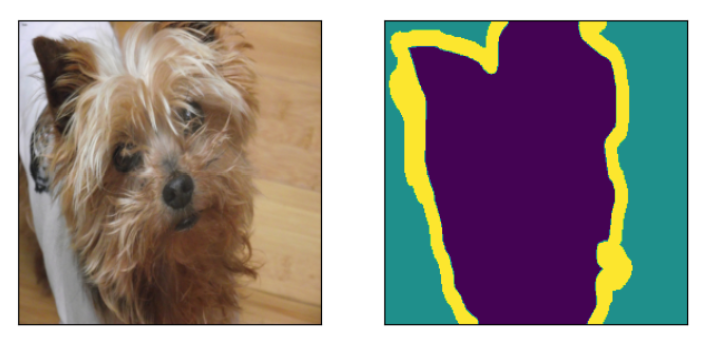



## Zadanie 0

Wczytaj zbiór OxfordIIIPet do zadania segmentacji, zbadaj co zawiera w środku oraz wyświetl przykładową maskę.

In [ ]:
import matplotlib.pyplot as plt
from torchvision import datasets
from pathlib import Path
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import time
import copy
from sklearn.metrics import accuracy_score
import torch.optim as optim

In [69]:


base_path = Path('/content')
IMG_SIZE = (128, 128)


transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])


target_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE, interpolation=transforms.InterpolationMode.NEAREST),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x * 255).long() - 1)
])

trainset = datasets.OxfordIIITPet(
    root=base_path,
    split='trainval',
    download=True,
    target_types='segmentation',
    transform=transform,
    target_transform=target_transform
)

testset = datasets.OxfordIIITPet(
    root=base_path,
    split='test',
    download=True,
    target_types='segmentation',
    transform=transform,
    target_transform=target_transform
)

train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_data, val_data = random_split(trainset, [train_size, val_size],
                                   generator=torch.Generator().manual_seed(67))

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, pin_memory=True)
test_loader = DataLoader(testset, batch_size=32, shuffle=False, pin_memory=True)

## U-Net

Jest to popularna architektura która ma swój początek w zadaniu **segmentacji** biomedycznej. Do tej pory mieliśmy styczność z klasyfikacją, gdzie każdemu obrazkowi przypisywaliśmy kategorię, natomiast segmentacja polega na przypisaniu każdemu pikselowi kategorii.

Architektura składa się z enkodera i dekodera, pośredniej warstwy bottlenecka i połączeń typu skip (aka' pomost). Sieć enkodera jest klasyczną siecią konwolucyjną, w której zwiększa się liczba kanałów kosztem zmniejszenia rozdzielczości mapy. Sieć dekodera składa się z warstw *dekonwolucji*, które mają w przeciwieństwie do zwykłej konwolucji zwiększać rozdzielczość obrazka i zmniejszać liczbę kanałów. Dzięki temu końcowy wynik ma taki sam rozmiar jak wejściowy obrazek, co reprezentuje przypisanie klasy per piksel. Połączenia pomostowe służą do konkatenacji map z enkodera i dekodera, a celem jest zachowanie informacji na temat tego "co" i "gdzie" się znajduje. Dobre wytłumaczenie znajduje się [tutaj](https://www.kaggle.com/code/akshitsharma1/unet-architecture-explained-in-one-shot-tutorial).

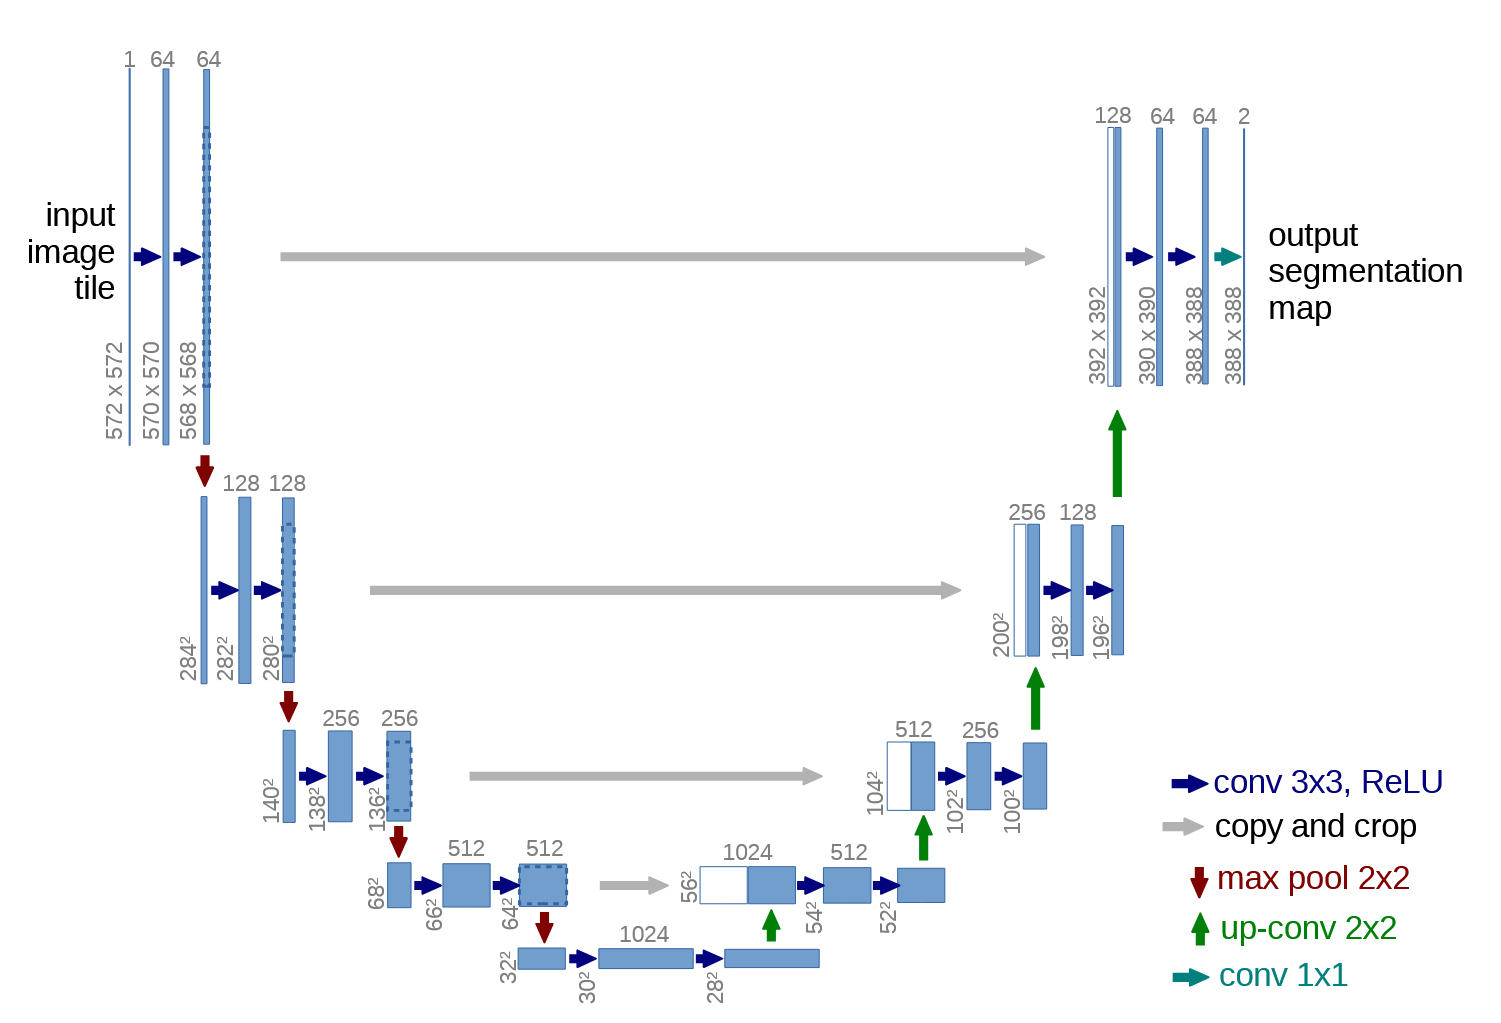

## Dekonwolucja

Dekonwolucja jest bratnią operacją konwolucji, ale jak już było wspomnianie, jej celem jest zwiększenie wymiarów przestrzennych. Składa się ona z kroków
- Upsampling: zwiększenie rozmiaru mapy zwykle dodając "puste" wiersze i kolumny
- Convolution: warstwa konwolucyjna (logiczne - czegoś też chcemy się nauczyć)
- Stride: $> 1$ zwiększa wymiar przestrzenny mapy
- Padding: to samo co w zwykłej konwolucji
- Activation: funkcja aktywacji (nieliniowa!, zwykle ReLU)

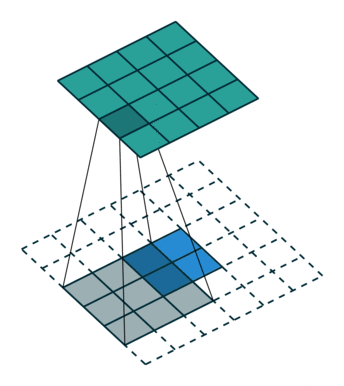

## Zadanie 1.1
Zaimplementuj blok warstwy enkodera, który będzie wykonywał m.in. operację konwolucji (zmniejszanie wymiary przestrzennego) oraz max-pooling. Jedną pułapką jest tutaj fakt, że enkoder musi zwracać dwie rzeczy - $x_{skip}$ jako wejście do dekodera, oraz $x_{down}$ po warstwie poolingu do dalszej warstwy enkodera.

$x_{skip} = ConvBlock(x)$

$x_{down} = MaxPool(x_{skip})$

gdzie $ConvBlock$ stanowi pipeline *konwolucja, batch-normalization, aktywacja* powtórzone $M$ razy (może być raz). Jest on już zaimplementowany niżej jako ```DoubleConv``` - możesz go dostosować do swoich potrzeb lub zostawić jak jest.

In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, hidden_channels: int = None):
        super().__init__()

        if not hidden_channels:
            hidden_channels = out_channels

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, hidden_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(hidden_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [ ]:
class DownBlock(nn.Module): # blok budulcowy enkodera

  def __init__(self, input, output): # dodaj parametry
    super().__init__()
    self.conv = DoubleConv(input, output)
    self.pool = nn.MaxPool2d(2)

  def forward(self, x):
    x_skip=self.conv(x)
    x_down=self.pool(x_skip)

    return x_skip, x_down

## Zadanie 1.2
Zaimplementuj *blok* warstwy dekodera, która będzie wykonywała operację dekonwolucji oraz konkatenacji cech z enkodera. Przetwarzanie powinno być według schematu:

*$x_{up} = ConvTranspose(x)$

$x_{cat} = Concat(x_{up}, s)$

$y = ConvBlock(x_{out})$

Nowa warstwa dekonwolucji jest zaimplementowana w torchu [ConvTranspose2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html). Należy zwrócić uwagę na **zgodność kształtów** oraz **liczbę kanałów** (szczególnie po konkatenacji!).

*alternatywnie można użyć warswty [Upsamplingu](https://docs.pytorch.org/docs/stable/generated/torch.nn.Upsample.html) + konwolucji

In [ ]:
class UpBlock(nn.Module): # blok budulcowy dekodera

  def __init__(self, input, output): # dodaj parametry
    super().__init__()
    self.transpose = nn.ConvTranspose2d(input, output, kernel_size=2, stride=2)
    self.conv = DoubleConv(output*2, output)

  def forward(self, x, s): # dodaj parametry
    x_up=self.transpose(x)
    x_cat=torch.cat((x_up, s), dim=1)
    x_out=self.conv(x_cat)
    return x_out

Zalecam zrobienie krótkiego sanity-check aby sprawdzić, czy dwa bloki łączą się poprawnie

In [ ]:
x = torch.randn(1, 3, 128, 128)
down_block = DownBlock(3,128) # dodaj argumenty
up_block = UpBlock(128,128) # dodaj argumenty

x_skip, x_down = down_block(x)
x_up = up_block(x_down, x_skip)

print(x_skip.shape, x_down.shape, x_up.shape)

## Zadanie 2.1
Następnym zadaniem jest wykorzystanie bloków do implementacji pełnej sieci. Niech nasza sieć składa się z N bloków enkodera $(E1​...En​)$, jednego bottlenecku $(B)$ i N bloków dekodera $(Dn​...D1​)$. Schemat będzie miał postać:

#### Enkoder
1. $(x1​,s1​)=E1​(input)$
2. $(x2​,s2​)=E2​(x1​)$
3. $(x3​,s3​)=E3​(x2​)$
4. $(x4​,s4​)=E4​(x3​)$

#### Bottleneck
5. $b=B(x4​)$ (zwykły blok konwolucyjny)

#### Dekoder
6. $d4​=D4​(b,s4​)$
7. $d3​=D3​(d4​,s3​)$
8. $d2​=D2​(d3​,s2​)$
9. $d1​=D1​(d2​,s1​)$

#### Spłaszczenie wyjścia
10. $output=Conv_{1x1}(d1​)$ --> wykorzystuje konwolucję $1x1$ do pozbycia się wymiaru kanału. Otrzymujemy tutaj $H \times W \times K$ predykcji (bo dla każdego piksela) i każdej klasy.

Wskazówki
- Rozmiar wejściowy: Musi być podzielny przez $2^{liczba poziomów}$ (dlaczego?), najlepiej używać potęg dwójki typu 256, 512
- Padding: równy 1
- Liczba kanałów: w enkoderze podwajamy $64 → 128 → 256$, w dekoderze dzielimy przez dwa $256 → 128 → 64$
- Konkatenacja: po wymiarze kanałów
- Wyjście: musi być takiego samo wymiary przestrzennego jak wejście, a liczba kanałów będzie odpowiadać liczbie klas.

In [ ]:
class UNet(nn.Module):
    def __init__(self, input, output, features=[64, 128, 256, 512]):
        super().__init__()
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()

        for f in features:
            self.encoder.append(DownBlock(input, f))
            input = f


        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        for f in reversed(features):
            self.decoder.append(UpBlock(f * 2, f))

        self.conv_final = nn.Conv2d(features[0], output, kernel_size=1)

    def forward(self, x):
        skip = []

        for down in self.encoder:
            x_skip, x = down(x)
            skip.append(x_skip)

        x = self.bottleneck(x)

        skip = skip[::-1]

        for i in range(len(self.decoder)):
            x = self.decoder[i](x, skip[i])

        return self.conv_final(x)

## Zadanie 2.2
Kolejnym krokiem jest wyuczenie sieci do zadania segmentacji. Wykorzystaj ```nn.CrossEntropyLoss``` jako funkcję straty (lub posłuż się bardziej dostosowanymi metrykami jak [Dice Loss](https://smp.readthedocs.io/en/latest/losses.html#diceloss) jeśli uczenie będzie szło bardzo źle). W tym celu konieczne będzie spłaszczenie wyniku $B \times W \times H \times K$ do $B \times (WH) \times K$. Wyświetl krzywą uczenia oraz dokładność dla każdej klasy. Dodatkowo zbieraj co $M$ epok przykładowe predykcje (dla zbioru walidacyjnego) i wyświetl jak w trakcie trenowania zmieniała się maska segmentacji (najlepiej zostaw dataloder dla zbioru val z ```shuffle=False```)

In [71]:
class Trainer:
    def __init__(self, model, optimizer, criterion, scheduler=None, patience=5, seed=None):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.optimizer = optimizer
        self.criterion = criterion
        self.scheduler = scheduler
        self.patience = patience
        self.seed = seed
        self.scaler = torch.amp.GradScaler('cuda')

        if self.seed is not None:
            torch.manual_seed(self.seed)
            np.random.seed(self.seed)
            if torch.cuda.is_available():
                torch.cuda.manual_seed(self.seed)
                torch.backends.cudnn.deterministic = True
                torch.backends.cudnn.benchmark = True

        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        self.saved_masks = []

    def train(self, train_loader, val_loader, n_epochs, save_path="best_model.pth"):
        best_loss = float('inf')
        best_model_wts = copy.deepcopy(self.model.state_dict())
        early_stop_counter = 0

        for epoch in range(n_epochs):
            self.model.train()
            train_loss = 0.0
            train_preds = []
            train_targets = []

            for inputs, labels in train_loader:
                inputs = inputs.to(self.device, non_blocking=True)
                labels = labels.to(self.device, non_blocking=True)

                self.optimizer.zero_grad(set_to_none=True)

                with torch.amp.autocast('cuda'):
                    outputs = self.model(inputs)
                    loss = self.criterion(outputs, labels.squeeze(1).long())

                self.scaler.scale(loss).backward()
                self.scaler.step(self.optimizer)
                self.scaler.update()

                train_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)

                train_preds.extend(preds.view(-1).cpu().numpy())
                train_targets.extend(labels.view(-1).cpu().numpy())

            epoch_train_loss = train_loss / len(train_loader.dataset)
            epoch_train_acc = accuracy_score(train_targets, train_preds)

            self.model.eval()
            val_loss = 0.0
            val_preds_acc = []
            val_targets_acc = []

            with torch.no_grad():
                for i, (inputs, labels) in enumerate(val_loader):
                    inputs = inputs.to(self.device, non_blocking=True)
                    labels = labels.to(self.device, non_blocking=True)

                    with torch.amp.autocast('cuda'):
                        outputs = self.model(inputs)
                        loss = self.criterion(outputs, labels.squeeze(1).long())

                    val_loss += loss.item() * inputs.size(0)
                    _, preds = torch.max(outputs, 1)

                    val_preds_acc.extend(preds.view(-1).cpu().numpy())
                    val_targets_acc.extend(labels.view(-1).cpu().numpy())

                    if i == 0:
                        self.saved_masks.append((
                            epoch + 1,
                            inputs[0].detach().cpu(),
                            labels[0].detach().cpu(),
                            preds[0].detach().cpu()
                        ))

            epoch_val_loss = val_loss / len(val_loader.dataset)
            epoch_val_acc = accuracy_score(val_targets_acc, val_preds_acc)

            self.history['train_loss'].append(epoch_train_loss)
            self.history['val_loss'].append(epoch_val_loss)
            self.history['train_acc'].append(epoch_train_acc)
            self.history['val_acc'].append(epoch_val_acc)

            if self.scheduler:
                if isinstance(self.scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                    self.scheduler.step(epoch_val_loss)
                else:
                    self.scheduler.step()

            current_lr = self.optimizer.param_groups[0]['lr']
            print(f"Epoka {epoch+1}/{n_epochs} (LR: {current_lr:.6f}) | "
                  f"Train Loss: {epoch_train_loss:.4f} Acc: {epoch_train_acc:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} Acc: {epoch_val_acc:.4f}")

            if epoch_val_loss < best_loss:
                best_loss = epoch_val_loss
                best_model_wts = copy.deepcopy(self.model.state_dict())
                torch.save(self.model.state_dict(), save_path)
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= self.patience:
                    print(f"\nEarly Stopping! Brak poprawy od {self.patience} epok.")
                    break

        self.model.load_state_dict(best_model_wts)
        return self.history

    def plot_history(self):
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.plot(self.history['train_loss'], label='Train Loss')
        plt.plot(self.history['val_loss'], label='Val Loss', linestyle='--')
        plt.title('Loss'); plt.xlabel('Epoch'); plt.legend()
        plt.subplot(1, 2, 2)
        plt.plot(self.history['train_acc'], label='Train Acc')
        plt.plot(self.history['val_acc'], label='Val Acc', linestyle='--')
        plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend()
        plt.show()

    def show_mask_evolution(self):
        n = len(self.saved_masks)
        if n == 0: return

        fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n), squeeze=False)
        for i, (ep, img, true, pred) in enumerate(self.saved_masks):
            axes[i, 0].imshow(np.clip(img.permute(1, 2, 0).numpy(), 0, 1))
            axes[i, 0].set_title(f"Epoka {ep}")
            axes[i, 0].axis('off')

            axes[i, 1].imshow(true.squeeze().numpy(), cmap='viridis')
            axes[i, 1].axis('off')

            axes[i, 2].imshow(pred.squeeze().numpy(), cmap='viridis')
            axes[i, 2].axis('off')
        plt.tight_layout()
        plt.show()

    def predict(self, test_loader):
        self.model.eval()
        inputs, labels = next(iter(test_loader))
        inputs = inputs.to(self.device)
        with torch.amp.autocast('cuda'):
            outputs = self.model(inputs)
        _, predicted = torch.max(outputs, 1)

        plt.figure(figsize=(15, 10))
        for i in range(min(5, len(inputs))):
            plt.subplot(3, 5, i + 1); plt.imshow(np.clip(inputs[i].cpu().permute(1,2,0), 0, 1)); plt.axis('off')
            plt.subplot(3, 5, i + 6); plt.imshow(labels[i].cpu().squeeze(), cmap='viridis'); plt.axis('off')
            plt.subplot(3, 5, i + 11); plt.imshow(predicted[i].cpu().squeeze(), cmap='viridis'); plt.axis('off')
        plt.tight_layout(); plt.show()

Epoka 1/5 (LR: 0.001000) | Train Loss: 0.6615 Acc: 0.7263 | Val Loss: 0.6015 Acc: 0.7578
Epoka 2/5 (LR: 0.001000) | Train Loss: 0.5499 Acc: 0.7812 | Val Loss: 0.5779 Acc: 0.7700
Epoka 3/5 (LR: 0.001000) | Train Loss: 0.4980 Acc: 0.8047 | Val Loss: 0.4835 Acc: 0.8121
Epoka 4/5 (LR: 0.001000) | Train Loss: 0.4638 Acc: 0.8191 | Val Loss: 0.6239 Acc: 0.7361
Epoka 5/5 (LR: 0.001000) | Train Loss: 0.4431 Acc: 0.8279 | Val Loss: 0.4713 Acc: 0.8211


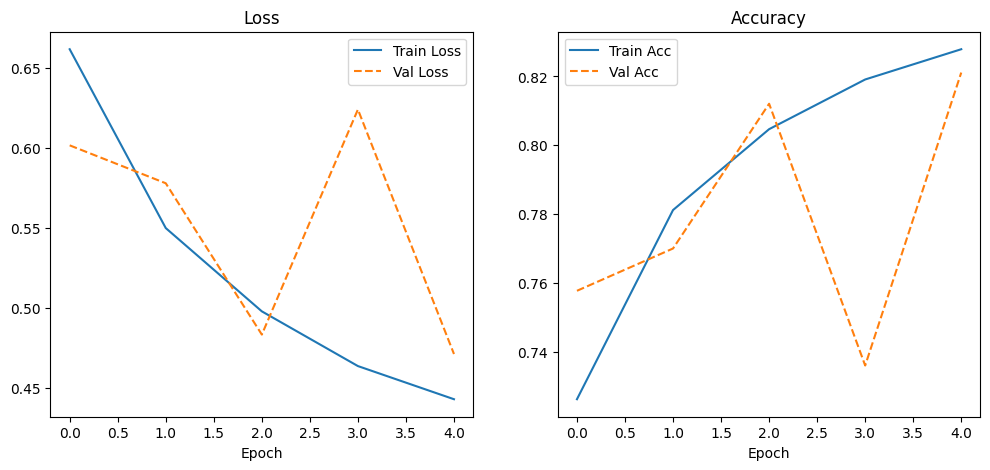

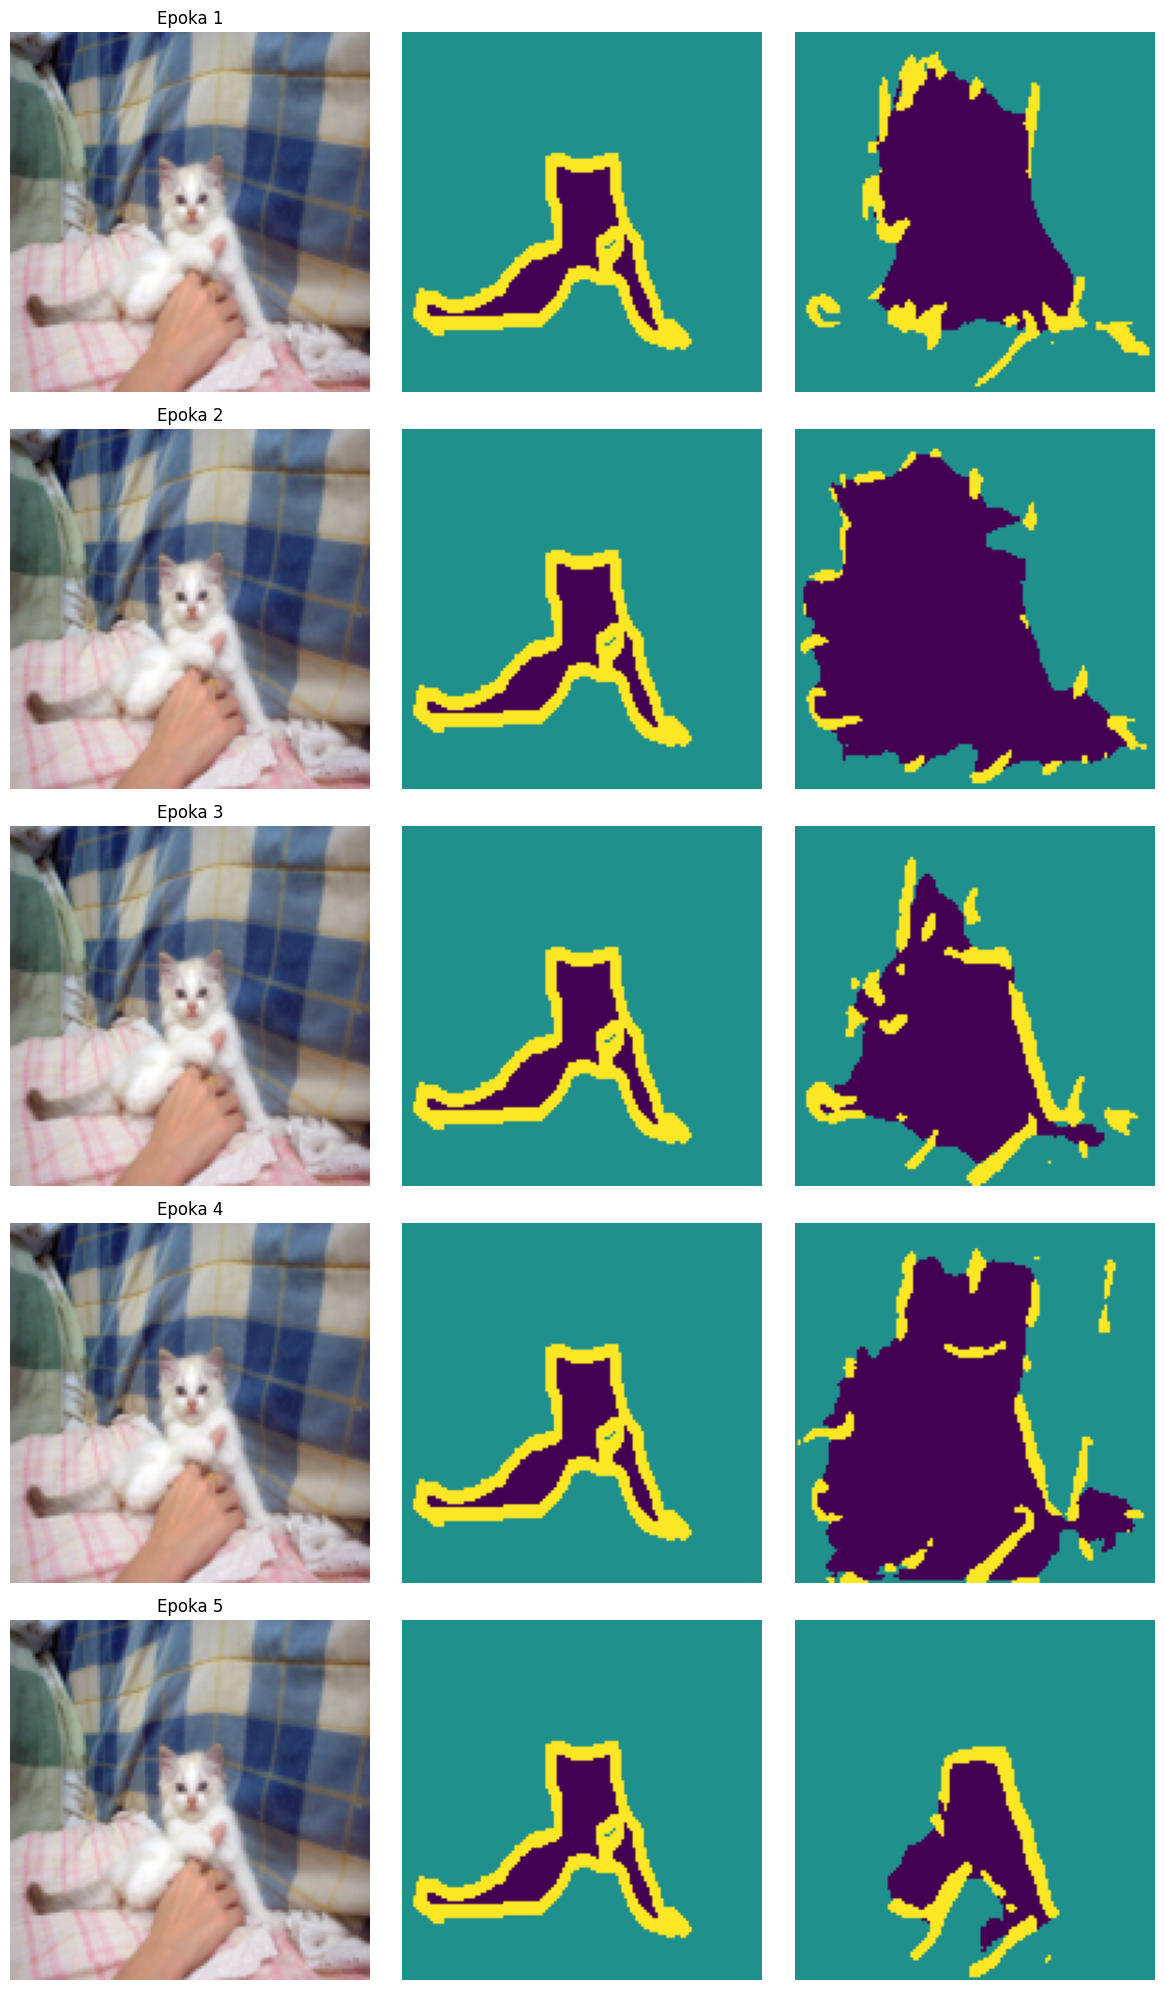

In [72]:
model = UNet(input=3, output=3)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


trainer = Trainer(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    patience=7,
    seed=42,
)


history = trainer.train(
    train_loader=train_loader,
    val_loader=val_loader,
    n_epochs=5,
    save_path="best_unet_pet.pth"
)

trainer.plot_history()
trainer.show_mask_evolution()

Jak widac maska idzie powoli w coraz lepsza strone

niestety uczenie było niestabilne co widac na wykresie

## Autoenkoder

Autoenkoder to architektura zaliczana do uczenia nienadzorowanego (unsupervised learning), co oznacza, że trenujemy ją wyłącznie na danych wejściowych, bez udziału etykiet. Model ten składa się z połączonego enkodera i dekodera, a jego celem jest minimalizacja błędu rekonstrukcji wejścia (np. Mean Squared Error).

Matematycznie problem ten sprowadza się do znalezienia takiego zbioru parametrów θ, który minimalizuje funkcję straty: $$ L(x^{(t)}, g_{\theta}(f_{\theta}(x^{(t)}))) $$ dla *enkodera* $f$ i *dekodera* $g$. Kluczową cechą jest to, że wymiar na wyjściu enkodera jest zazwyczaj mniejszy niż danych wejściowych. Ma to na celu wymuszenie kompresji danych do tzw. przestrzeni ukrytej (latent space), co zapobiega nauczeniu się przez sieć trywialnej funkcji tożsamościowej. Dekoder zajmuje się następnie rekonstrukcją oryginalnego obrazu na podstawie tej skompresowanej reprezentacji.

Bardzo dobrą praktyką jest celowe zaszumianie danych wejściowych na etapie treningu. Działa to jak silna regularyzacja – enkoder musi wtedy nauczyć się ekstrahować najważniejsze, kluczowe cechy danych, aby być w stanie odtworzyć czysty sygnał. Tak wytrenowany autoenkoder znajduje zastosowanie głównie w tworzeniu zwartych osadzeń danych (embeddingów), które mogą zostać wykorzystane w dalszych etapach, np. w zadaniu klasyfikacji.

### Przepływ danych

1. Enkoder: zajmuje się kompresją wejściowego obrazu, zwykle do zmniejszania rozmiaru przestrzennego używamy $stride=2$ zamiast max-pooling.
2. Bottleneck: punkt największej kompresji, wykorzystuje znany już $AdaptiveAvgPool2d$ aby wymusić mały rozmiar przestrzenny (np. $2 \times 2$) do dekodowania
3. Dekoder: odbudowuje obraz z wykorzystaniem wcześniej omawianych transponowanych konwolucji.

### Funkcja straty
Wykorzystamy funkcję straty [MSE](https://docs.pytorch.org/docs/stable/generated/torch.nn.MSELoss.html#mseloss) do porównania obrazu wejściowego i zrekonstruowanego. Alternatywnie może być wykorzystane [MAE](https://docs.pytorch.org/docs/stable/generated/torch.nn.L1Loss.html) ponieważ jest mniej odporne na wartości odstające. Wartości obrazu powinny być znormalizowane, ale wyjścia sieci nie muszą być ograniczone.

## Zadanie 3.1

Zaimplementuj sieć autoenkoder. Będzie ona podobna do sieci U-Net, natomiast nie używa *skip connections* do połączenia dwóch części (ma prostszy schemat). Wyucz sieć traktując obraz wejściowy jako "labele" (pamiętamy, że jest to zadanie nienadzorowane, ale nadal potrzebujemy jakiegoś ground-truth). Wyświetl ciekawsze przykłady rekonstrukcji i zawrzyj wnioski na temat łatwości uczenia sieci i jakości zrekonstruowanych obrazów.

**Uwaga**: możecie wczytać zbiór danych do nauki na wszytkich $37$ klasach, lub tylko na klasach binarnych - dla **target_types=binary-category**. Nie ma to oczywiście znaczenia do nauki autoenkodera, ale w zadaniu 3.2 potrzebne są kategorie - być może lepiej będzie zwizualizować tylko jak przestrzeń się układa dla psów i kotów, niż dla każdej z 37 klas.

In [43]:


base_path = Path('/content')
IMG_SIZE = (128, 128)


transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])



trainset = datasets.OxfordIIITPet(
    root=base_path,
    split='trainval',
    download=True,
    target_types='binary-category',
    transform=transform,
)

testset = datasets.OxfordIIITPet(
    root=base_path,
    split='test',
    download=True,
    target_types='binary-category',
    transform=transform,

)

train_size = int(0.8 * len(trainset))
val_size = len(trainset) - train_size
train_data, val_data = random_split(trainset, [train_size, val_size],
                                   generator=torch.Generator().manual_seed(67))

train_loader = DataLoader(train_data, batch_size=128, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, pin_memory=True)
test_loader = DataLoader(testset, batch_size=128, shuffle=False, pin_memory=True)

In [44]:
class Encoder(nn.Module): # oddzielne sieci dla przejrzystości i łatwości dalszego użycia

  def __init__(self, input, output):
    super().__init__()
    self.conv = nn.Conv2d(input, output, kernel_size=3, padding=1, bias=False, stride=2)

  def forward(self,x):
    return self.conv(x)


In [45]:
class Decoder(nn.Module):

  def __init__(self, input, output):
    super().__init__()
    self.trans=nn.ConvTranspose2d(input, output, kernel_size=2, stride=2)

  def forward(self,x):
    return self.trans(x)

In [58]:
import torch.nn.functional as F

class CNNAutoencoder(nn.Module):
    def __init__(self, input_ch, b_size):
        super().__init__()
        self.encoder = Encoder(input_ch, 16)
        self.decoder = Decoder(16, input_ch)
        self.bottleneck = nn.AdaptiveAvgPool2d((b_size, b_size))

    def embeddings(self, x):
        x = self.encoder(x)
        x = self.bottleneck(x)
        return torch.flatten(x, 1)

    def forward(self, x):
        size = x.shape[-2:]
        x = self.encoder(x)
        x = self.bottleneck(x)
        x = self.decoder(x)
        if x.shape[-2:] != size:
            x = F.interpolate(x, size=size, mode='bilinear', align_corners=False) #wymiary nie taki ;()
        return x


In [64]:
import torch
import numpy as np
import copy
import matplotlib.pyplot as plt

class Trainer:
    def __init__(self, model, optimizer, criterion, patience=5):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.optimizer = optimizer
        self.criterion = criterion
        self.patience = patience


        self.scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None

        self.history = {'train_loss': [], 'val_loss': []}
        self.evolution = []
    def train(self, train_loader, val_loader, n_epochs, save_path="best_ae.pth"):
        best_loss = float('inf')
        best_model_wts = copy.deepcopy(self.model.state_dict())
        early_stop_counter = 0

        for epoch in range(n_epochs):

            self.model.train()
            train_running_loss = 0.0

            for inputs, _ in train_loader:

                inputs = inputs.to(self.device, non_blocking=True)

                self.optimizer.zero_grad(set_to_none=True)


                with torch.amp.autocast('cuda', enabled=(self.scaler is not None)):
                    outputs = self.model(inputs)

                    loss = self.criterion(outputs, inputs)

                if self.scaler:
                    self.scaler.scale(loss).backward()
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                else:
                    loss.backward()
                    self.optimizer.step()

                train_running_loss += loss.item() * inputs.size(0)

            epoch_train_loss = train_running_loss / len(train_loader.dataset)


            self.model.eval()
            val_running_loss = 0.0

            with torch.no_grad():
                for i, (inputs, _) in enumerate(val_loader):
                    inputs = inputs.to(self.device, non_blocking=True)

                    with torch.amp.autocast('cuda', enabled=(self.scaler is not None)):
                        outputs = self.model(inputs)
                        loss = self.criterion(outputs, inputs)

                    val_running_loss += loss.item() * inputs.size(0)


                    if i == 0:
                        self.evolution.append((
                            epoch + 1,
                            inputs[0].detach().cpu(),
                            outputs[0].detach().cpu()
                        ))

            epoch_val_loss = val_running_loss / len(val_loader.dataset)

            self.history['train_loss'].append(epoch_train_loss)
            self.history['val_loss'].append(epoch_val_loss)

            print(f"Epoka {epoch+1}/{n_epochs} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")


            if epoch_val_loss < best_loss:
                best_loss = epoch_val_loss
                best_model_wts = copy.deepcopy(self.model.state_dict())
                torch.save(self.model.state_dict(), save_path)
                early_stop_counter = 0
            else:
                early_stop_counter += 1
                if early_stop_counter >= self.patience:
                    print(f"Early stopping w epoce {epoch+1}")
                    break

        self.model.load_state_dict(best_model_wts)
        return self.history

    def show_reconstruction_evolution(self):
        n = len(self.evolution)
        if n == 0:
            print("Brak danych do wyświetlenia ewolucji.")
            return

        fig, axes = plt.subplots(n, 2, figsize=(8, 3 * n), squeeze=False)

        for i, (epoch, orig, recon) in enumerate(self.evolution):

            img_orig = orig.permute(1, 2, 0).numpy()
            img_orig = np.clip(img_orig, 0, 1)

            axes[i, 0].imshow(img_orig)
            axes[i, 0].set_title(f"Oryginał (Epoka {epoch})")
            axes[i, 0].axis('off')

            img_recon = recon.permute(1, 2, 0).numpy()
            img_recon = np.clip(img_recon, 0, 1)

            axes[i, 1].imshow(img_recon)
            axes[i, 1].set_title(f"Rekonstrukcja (Epoka {epoch})")
            axes[i, 1].axis('off')

        plt.tight_layout()
        plt.show()

    def plot_loss(self):
        plt.plot(self.history['train_loss'], label='Train Loss')
        plt.plot(self.history['val_loss'], label='Val Loss')
        plt.title('Krzywa uczenia')
        plt.legend()
        plt.show()

### Zadanie 3.2
Wyucz sieć autoeknkodera. Klasycznie loguj funkcję straty (czy będziesz logować accuracy??), oraz zbieraj rekonstrukcje dla zbioru walidacyjnego w trakcie uczenia i wyświetl jak się zmieniały w trakcie trenowania. Eksperymenty wykonaj dla różnej wielkości *bottlenecka* (np. $4, 16, 32$) i zapisz swoje obserwacje.

EKSPERYMENT: Bottleneck 2x2
Epoka 1/5 | Train Loss: 0.225264 | Val Loss: 0.132768
Epoka 2/5 | Train Loss: 0.089737 | Val Loss: 0.056948
Epoka 3/5 | Train Loss: 0.052479 | Val Loss: 0.047040
Epoka 4/5 | Train Loss: 0.046753 | Val Loss: 0.044238
Epoka 5/5 | Train Loss: 0.045164 | Val Loss: 0.043493
EKSPERYMENT: Bottleneck 4x4
Epoka 1/5 | Train Loss: 0.235407 | Val Loss: 0.125824
Epoka 2/5 | Train Loss: 0.080578 | Val Loss: 0.054056
Epoka 3/5 | Train Loss: 0.045138 | Val Loss: 0.038181
Epoka 4/5 | Train Loss: 0.035569 | Val Loss: 0.034114
Epoka 5/5 | Train Loss: 0.033225 | Val Loss: 0.032940
EKSPERYMENT: Bottleneck 6x6
Epoka 1/5 | Train Loss: 0.291714 | Val Loss: 0.164340
Epoka 2/5 | Train Loss: 0.101091 | Val Loss: 0.048842
Epoka 3/5 | Train Loss: 0.035871 | Val Loss: 0.030234
Epoka 4/5 | Train Loss: 0.027638 | Val Loss: 0.026541
Epoka 5/5 | Train Loss: 0.025360 | Val Loss: 0.025298


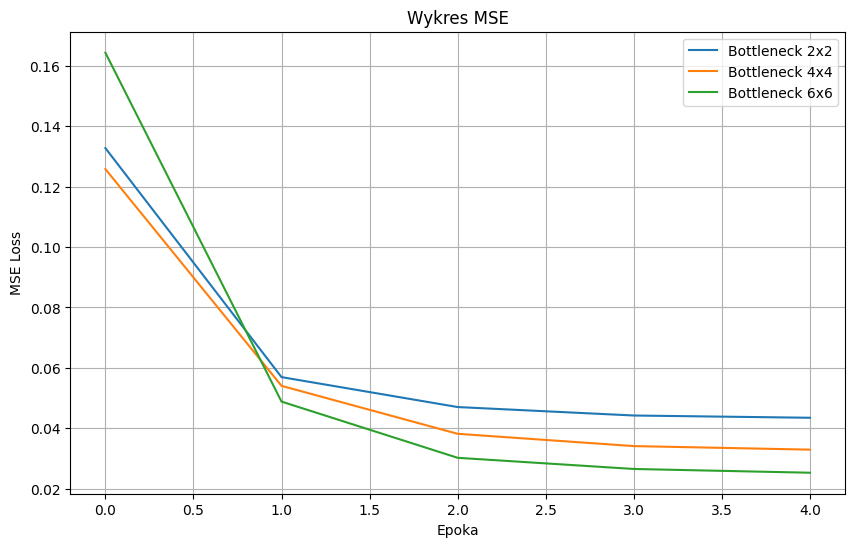


Ewolucja rekonstrukcji dla Bottleneck 2x2:


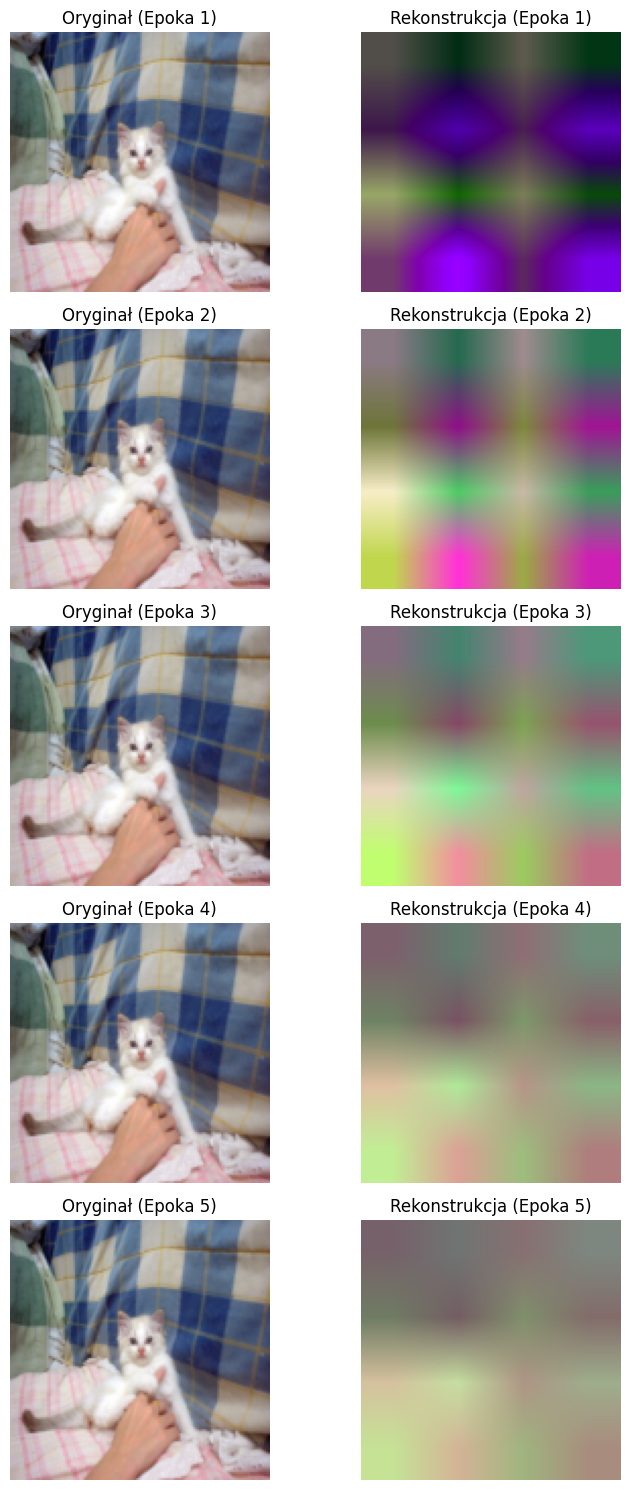


Ewolucja rekonstrukcji dla Bottleneck 4x4:


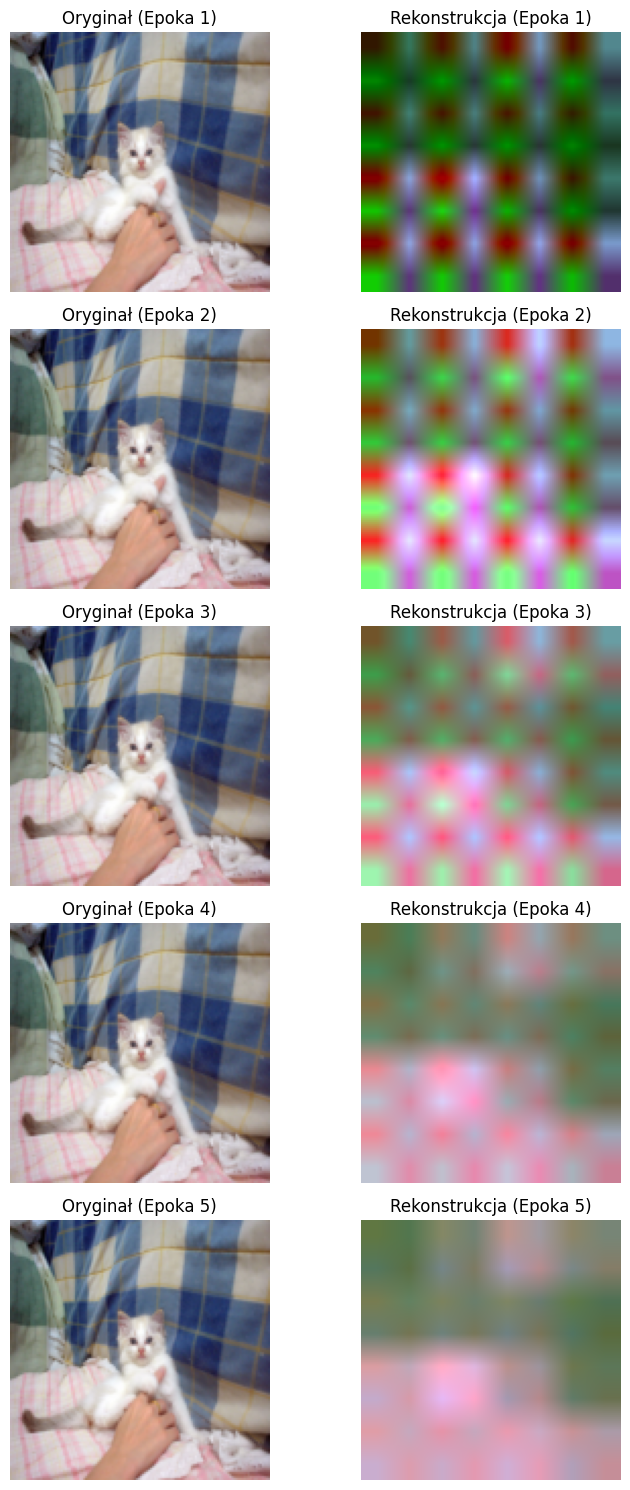


Ewolucja rekonstrukcji dla Bottleneck 6x6:


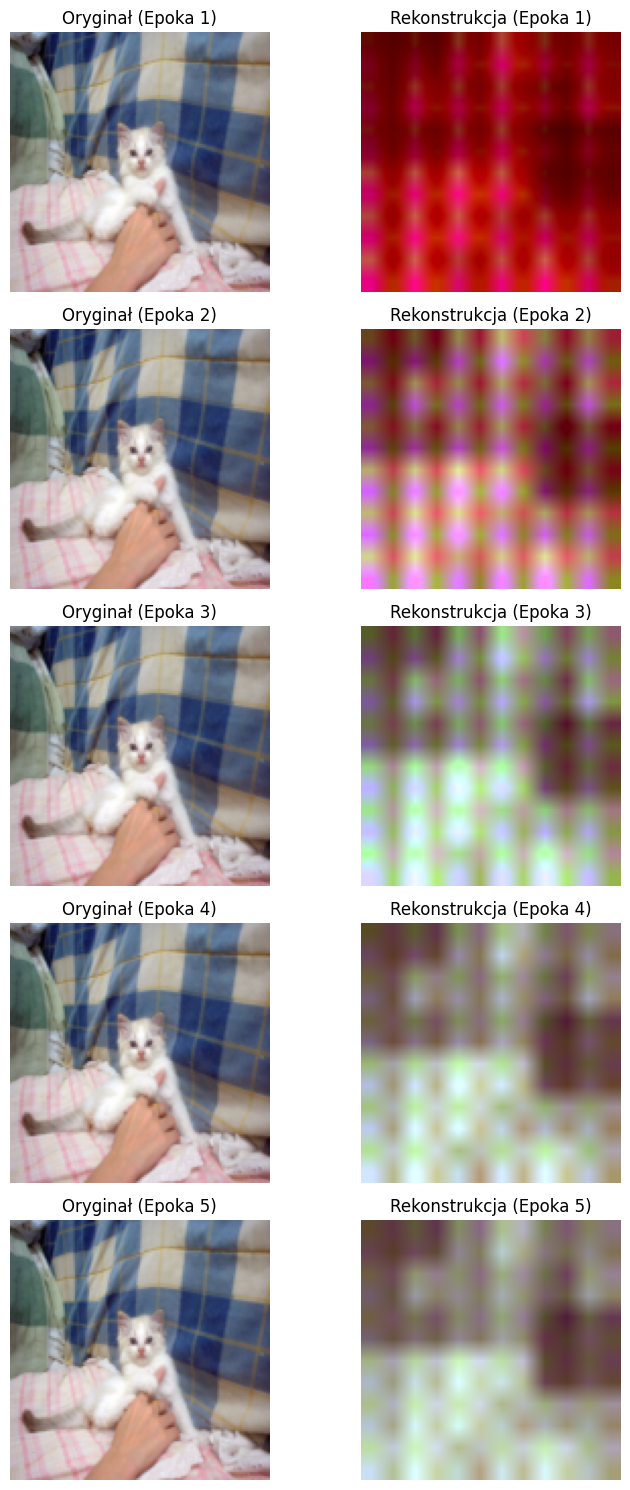

In [66]:

results = {}
bottleneck_sizes = [2, 4, 6]

for b_size in bottleneck_sizes:
    print(f"EKSPERYMENT: Bottleneck {b_size}x{b_size}")


    model = CNNAutoencoder(input_ch=3, b_size=b_size)


    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.MSELoss()

    trainer = Trainer(
        model=model,
        optimizer=optimizer,
        criterion=criterion,
        patience=5
    )


    history = trainer.train(train_loader, val_loader, n_epochs=5)
    results[b_size] = {
        'history': history,
        'trainer': trainer
    }


plt.figure(figsize=(10, 6))
for b_size in bottleneck_sizes:
    plt.plot(results[b_size]['history']['val_loss'], label=f'Bottleneck {b_size}x{b_size}')

plt.title('Wykres MSE')
plt.xlabel('Epoka')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()


for b_size in bottleneck_sizes:
    print(f"\nEwolucja rekonstrukcji dla Bottleneck {b_size}x{b_size}:")
    results[b_size]['trainer'].show_reconstruction_evolution()


widac ze probuje odzyskac obrazek ale cos nie idzie, jakosc jest bardzo niska, moze czegos bkuje

## *Zadanie 3.3
Zwizualizuj wektor osadzeń przy pomocy *T-SNE*. Do tego celu potrzeba będzie spłaszczyć mapę powstałą w wyniku przejścia przez enkoder. Nie jest tutaj potrzebna sieć dekodera. Zwróć uwagę na to, czy klasy są wizualnie dobrze rozdzielone.